In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-dataset' dataset.
Path to dataset files: /kaggle/input/weather-dataset


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [32]:
data = pd.read_csv(r'/root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1/weatherHistory.csv')

In [33]:
len(data)

96453

In [34]:
data.duplicated().sum()

np.int64(24)

In [35]:
data = data.dropna()
data = data.drop_duplicates()
len(data)

95912

In [14]:
data.head(5)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [36]:
set(data['Loud Cover'])

{0.0}

In [37]:
data = data.drop(['Formatted Date','Daily Summary','Summary', 'Precip Type', 'Loud Cover'], axis=1)
data.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


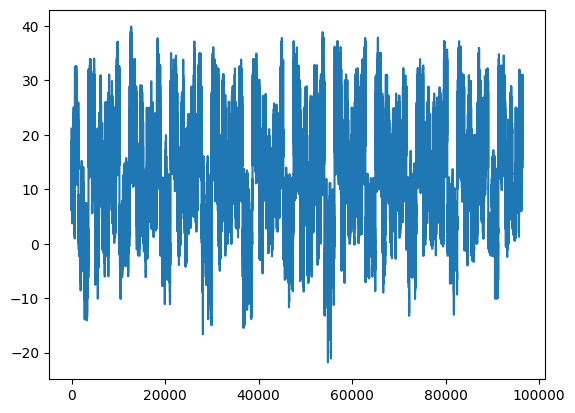

In [38]:
plt.plot(data['Temperature (C)'])
plt.show()
# plt.plot(data['Pressure (millibars)'], data['Humidity'])


In [107]:
import torch
import torch.nn as nn
class Simple1DCNN(nn.Module):
  def __init__(self):
    super(Simple1DCNN, self).__init__()
    self.conv1 = nn.Conv1d(in_channels=6, out_channels=32, kernel_size=3)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3)
    self.conv3 = nn.Conv1d(in_channels=16, out_channels=1, kernel_size=3)
  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    logits = self.conv3(x)

    # pred = torch.sigmoid(x)
    return logits

model = Simple1DCNN()

In [95]:
Y_dataset = data['Temperature (C)']
X_dataset = data.drop(columns=['Temperature (C)'])
X_dataset = torch.tensor(X_dataset.values, dtype=torch.float)
Y_dataset = torch.tensor(Y_dataset.values, dtype=torch.float).unsqueeze(1)
X_dataset
len(Y_dataset)

95912

In [96]:
len(X_dataset)

95912

In [97]:
window = 23
X = []
Y = []
for i in range(len(X_dataset) - window):
    X.append(X_dataset[i:i+window].T)
    Y.append(Y_dataset[i+window])

X = torch.stack(X)
Y = torch.stack(Y).unsqueeze(1)

In [100]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [112]:
import torch.optim as optim
criteria = nn.L1Loss()
lossi = []
cnt = 0
epoch = 100
optimizer = optim.Adam(model.parameters(), lr=0.001)
for i in range(epoch):
  epoch_loss=0
  for x, y in loader:
    pred = model(x)
    loss = criteria(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss+=loss.item()
  epoch_loss/=len(loader)
  lossi.append(epoch_loss)
  print(f'Epoch={i+1}, loss={epoch_loss}')
  cnt+=1


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([128, 1, 1])) that is different to the input size (torch.Size([128, 1, 17])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([17, 1, 1])) that is different to the input size (torch.Size([17, 1, 17])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch=0, loss=5.145611578941345
Epoch=1, loss=4.927548911253611
Epoch=2, loss=4.866497322718303
Epoch=3, loss=4.8158866626421615
Epoch=4, loss=4.781290756543477
Epoch=5, loss=4.751694381713867
Epoch=6, loss=4.720528355439504
Epoch=7, loss=4.709463823954264
Epoch=8, loss=4.680668451150258
Epoch=9, loss=4.663952991485596
Epoch=10, loss=4.647277599652608
Epoch=11, loss=4.629940995534261
Epoch=12, loss=4.609536778767904
Epoch=13, loss=4.590934020678202
Epoch=14, loss=4.570777686754862
Epoch=15, loss=4.556220906416575
Epoch=16, loss=4.537493254184723
Epoch=17, loss=4.526978177388509
Epoch=18, loss=4.514023721694946
Epoch=19, loss=4.492881243864695
Epoch=20, loss=4.437939270019531
Epoch=21, loss=4.347491283734639
Epoch=22, loss=4.307514879067739
Epoch=23, loss=4.2910798530578615
Epoch=24, loss=4.262239608605703
Epoch=25, loss=4.234535667419434
Epoch=26, loss=4.212890076955159
Epoch=27, loss=4.191238391717275
Epoch=28, loss=4.182707495689392
Epoch=29, loss=4.168477743784587
Epoch=30, loss=4.1

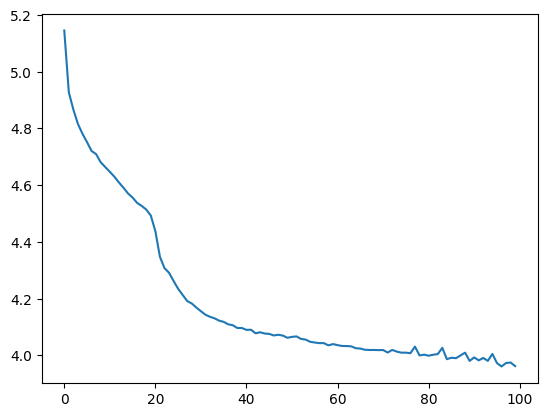

In [113]:
plt.plot(lossi)